<a href="https://colab.research.google.com/github/nichmars/Johnson-Center-GVSU-Final-Project/blob/main/aggregate_pct_change.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import io
import pandas as pd
import numpy as np
import sklearn.model_selection
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')
file_name = '/content/drive/MyDrive/MTH498 Project/Filtered Data with Subtypes Again.xlsx'

df = pd.read_excel(file_name)

df.replace('Single Issue', 'Single Issue Charity', inplace=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sklearn.model_selection import train_test_split

metrics = ["Accounts", "Contributions", "Grants", "Assets"]

# Split EINs into train/test
unique_eins = df["ein"].unique()

train_eins, test_eins = train_test_split(
    unique_eins,
    test_size=0.25,
    random_state=42
)

train_df = df[df["ein"].isin(train_eins)].copy()
test_df = df[df["ein"].isin(test_eins)].copy()

print(df.to_string())

Dataframe has 9023 rows

Training set has 6816

Test set has 2207

Things to test:


*   scaled vs. unscaled groupings
*   different number of groupings
* sorting into quartiles by numerical values
* removing "year" as one of the predictor variables
* weighing type and subtype more heavily
* create visualization of the clustering!!!
* should go back and test this on Johnson Center's method

In [ ]:
# List of metrics we want to analyze
metrics = ["Accounts", "Contributions", "Grants", "Assets"]

# Calculate the difference in years for each 'ein' to check for consecutive years
train_df = train_df.sort_values(["ein", "Year"])
train_df["year_diff"] = train_df.groupby("ein")["Year"].diff()

test_df = test_df.sort_values(["ein", "Year"])
test_df["year_diff"] = test_df.groupby("ein")["Year"].diff()

df = df.sort_values(["ein", "Year"])
df["year_diff"] = df.groupby("ein")["Year"].diff()


# Loop through each metric to calculate percent change
# Use .replace(np.nan, 0) to catch 0/0 errors and manually adjust the percent change to 0
for m in metrics:
    pct_col = f"{m.lower()}_pct_change"

    df[pct_col] = train_df.groupby("ein")[m].pct_change().replace(np.nan, 0)
    train_df[pct_col] = train_df.groupby("ein")[m].pct_change().replace(np.nan, 0)
    df.loc[df["year_diff"] != 1, pct_col] = None


# Calculating aggregate percent change
for m in metrics:
    pct_col = f"{m.lower()}_pct_change"

    # Compute yearly sums from training data
    year_sums = (
        train_df.loc[train_df[m].notna()]
        .groupby("Year")[m]
        .sum()
        .sort_index()
    )

    # Compute year-over-year percent change
    pct_change = year_sums.pct_change()

    # Map to train and test data by Year
    df[pct_col] = df["Year"].map(pct_change)
    test_df[pct_col] = test_df["Year"].map(pct_change)



#print(test_df)
#print(df.to_string())
# df['contributions_pct_change'].count()
# df.columns
#print(train_df[f"{m.lower()}_group"].value_counts())
#print(test_df[f"{m.lower()}_group"].value_counts())
df


,ein,Year,Accounts,Contributions,Grants,Assets,Type,subtype,year_diff,accounts_pct_change,contributions_pct_change,grants_pct_change,assets_pct_change
0,10391479,2007,270,13347384.0,10628512,95282896.0,Community Foundation,Community,NaN,NaN,NaN,NaN,NaN
1,10391479,2008,276,8389212.0,7419626,68897739.0,Community Foundation,Community,1.0,0.144737,-0.159079,0.066428,0.045153
2,10391479,2009,278,10016375.0,8857052,83057576.0,Community Foundation,Community,1.0,0.072710,-0.241592,-0.130117,-0.004064
3,10391479,2010,284,14088617.0,7569699,97807493.0,Community Foundation,Community,1.0,0.047898,0.364163,0.149749,0.161226
4,10391479,2011,296,19783555.0,9802671,106056922.0,Community Foundation,Community,1.0,0.078809,0.107337,0.065541,0.121448
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9018,841612422,2007,0,0.0,0,0.0,Single Issue Charity,Other,NaN,NaN,NaN,NaN,NaN
9019,841682682,2007,0,0.0,0,0.0,Community Foundation,Community,NaN,NaN,NaN,NaN,NaN
9020,920146538,2021,1,0.0,0,12500.0,Single Issue Charity,Other,NaN,0.261635,0.862834,0.517527,0.449711
9021,941312348,2008,1,700000.0,0,100000.0,Single Issue Charity,Other,NaN,0.144737,-0.159079,0.066428,0.045153


In [ ]:
# Predict next year's value using each org's bracket-specific median growth
for m in metrics:
    prev_actual = test_df.groupby("ein")[m].shift(1)
    test_df[f"predicted_{m.lower()}"] = prev_actual * (1 + test_df[f"{m.lower()}_pct_change"])

In [ ]:
# Convert predicted columns to numeric and replace invalid values
pred_cols = ["predicted_accounts", "predicted_contributions", "predicted_grants", "predicted_assets"]

for col in pred_cols:
    df[col] = pd.to_numeric(test_df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# Function to calculate Median Relative Deviation
def MRD(actual_col, predicted_col):
    valid_rows = df[df[predicted_col].notna() &
                    df[actual_col].notna() &
                    (df[actual_col] != 0) &
                    (df["year_diff"] == 1)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = (abs((total_actual - total_predicted)) / total_actual).median()
    return RE

def mean_relative_error(actual_col, predicted_col):
    valid_rows = df[df[predicted_col].notna() & df[actual_col].notna() & (df[actual_col] != 0) & (df["year_diff"] == 1)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = (abs((total_actual - total_predicted))/total_actual).mean()
    return RE

def smape(actual_col, predicted_col):
    valid_rows = df[
        df[predicted_col].notna() &
        df[actual_col].notna() &
        (df["year_diff"] == 1)
    ]

    A = valid_rows[actual_col]
    P = valid_rows[predicted_col]

    return np.mean(np.abs(A - P) / ((np.abs(A) + np.abs(P)) / 2))

# Compute relative errors
RE_account = MRD("Accounts", "predicted_accounts")
RE_contributions = MRD("Contributions", "predicted_contributions")
RE_grants = MRD("Grants", "predicted_grants")
RE_assets = MRD("Assets", "predicted_assets")

Mean_account = mean_relative_error("Accounts", "predicted_accounts")
Mean_contributions = mean_relative_error("Contributions", "predicted_contributions")
Mean_grants = mean_relative_error("Grants", "predicted_grants")
Mean_assets = mean_relative_error("Assets", "predicted_assets")

smape_account = smape("Accounts", "predicted_accounts")
smape_contributions = smape("Contributions", "predicted_contributions")
smape_grants = smape("Grants", "predicted_grants")
smape_assets = smape("Assets", "predicted_assets")

print("Median Relative Deviation - Account:", abs(RE_account))
print("Median Relative Deviation - Contributions:", abs(RE_contributions))
print("Median Relative Deviation - Grants:", abs(RE_grants))
print("Median Relative Deviation - Assets:", abs(RE_assets))

print("")
print("Mean Relative Deviation - Account:", abs(Mean_account))
print("Mean Relative Deviation - Contributions:", abs(Mean_contributions))
print("Mean Relative Deviation - Grants:", abs(Mean_grants))
print("Mean Relative Deviation - Assets:", abs(Mean_assets))

print("")
print("SMAPE - Account:", abs(smape_account))
print("SMAPE - Contributions:", abs(smape_contributions))
print("SMAPE - Grants:", abs(smape_grants))
print("SMAPE - Assets:", abs(smape_assets))

Median Relative Deviation - Account: 0.09600748946543333
Median Relative Deviation - Contributions: 0.5197463941615652
Median Relative Deviation - Grants: 0.3450728833164225
Median Relative Deviation - Assets: 0.1531760280242782

Mean Relative Deviation - Account: 0.21137261486433692
Mean Relative Deviation - Contributions: 3.2861079604029615
Mean Relative Deviation - Grants: 1.8752541843799853
Mean Relative Deviation - Assets: 0.9606818392540754

SMAPE - Account: 0.17733491402931822
SMAPE - Contributions: 0.7100420296277019
SMAPE - Grants: 0.5160890286843565
SMAPE - Assets: 0.24310209462726357


In [ ]:
#df.to_excel("output.xlsx", index=False)

In [ ]:
df["Actual Error Accounts"] = -(df["Accounts"] - df["predicted_accounts"])/df["Accounts"]
df["Actual Error Contributions"] = -(df["Contributions"] - df["predicted_contributions"])/df["Contributions"]
df["Actual Error Grants"] = -(df["Grants"] - df["predicted_grants"])/df["Grants"]
df["Actual Error Assets"] = -(df["Assets"] - df["predicted_assets"])/df["Assets"]

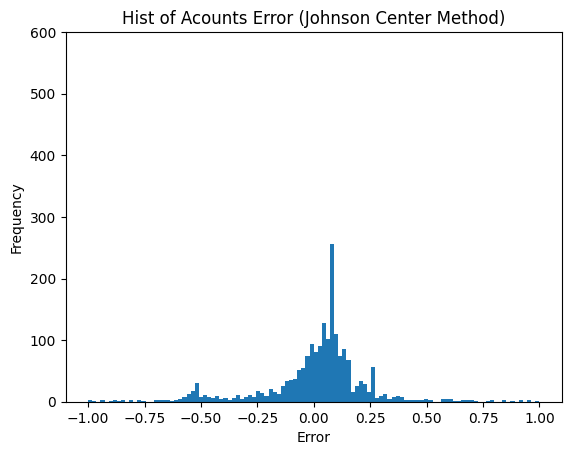

In [ ]:
import matplotlib.pyplot as plt

df_error_accounts = df[~np.isinf(df['Actual Error Accounts'])]
cleaned_errors_accounts = [x for x in df_error_accounts['Actual Error Accounts'] if not np.isnan(x) and x < 1 ]

#print(cleaned_errors_accounts)

plt.hist(cleaned_errors_accounts, bins = 110)

plt.title("Hist of Acounts Error (Johnson Center Method)")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.ylim(0, 600) #
plt.show()

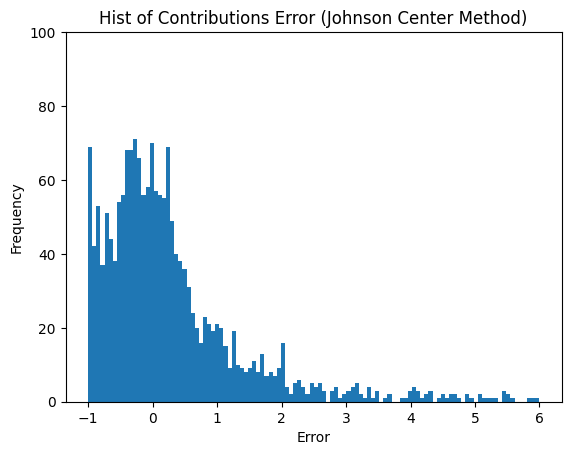

In [ ]:
df_error_contributions = df[~np.isinf(df['Actual Error Contributions'])]
cleaned_errors_contributions = [x for x in df_error_contributions['Actual Error Contributions'] if not np.isnan(x) and x < 6 ]

#print(cleaned_errors_contributions)

plt.hist(cleaned_errors_contributions, bins = 110)

plt.title("Hist of Contributions Error (Johnson Center Method)")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.ylim(0, 100) #
plt.show()

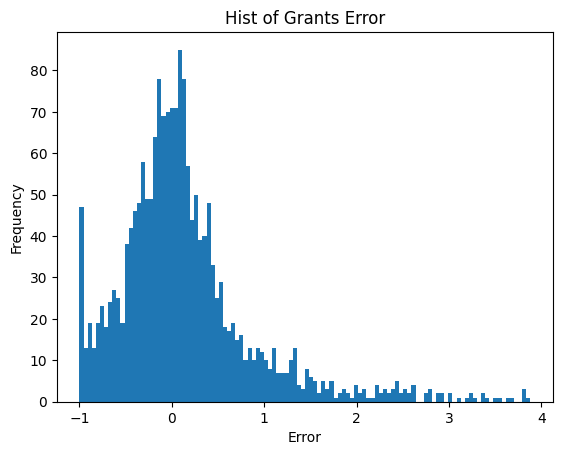

In [ ]:
df_error_grants = df[~np.isinf(df['Actual Error Grants'])]
cleaned_errors_grants = [x for x in df_error_grants['Actual Error Grants'] if not np.isnan(x) and x < 4 ]

#print(cleaned_errors_grants)

plt.hist(cleaned_errors_grants, bins = 110)

plt.title("Hist of Grants Error")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.show()

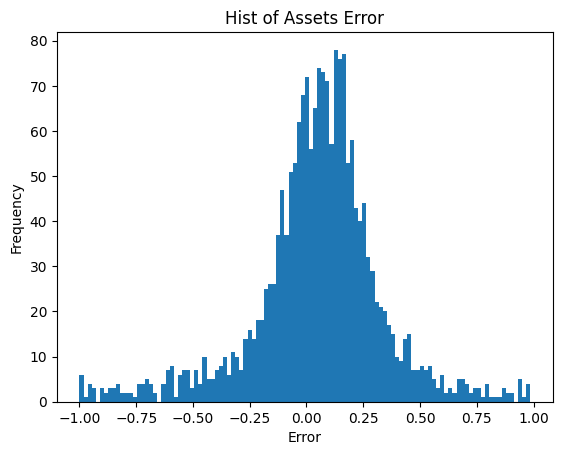

In [ ]:
df_error_assets = df[~np.isinf(df['Actual Error Assets'])]
cleaned_errors_assets = [x for x in df_error_assets['Actual Error Assets'] if not np.isnan(x) and x < 1 ]

#print(cleaned_errors_assets)

plt.hist(cleaned_errors_assets, bins = 110)

plt.title("Hist of Assets Error")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.show()

/tmp/ipykernel_667/2572071959.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
/tmp/ipykernel_667/2572071959.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
/tmp/ipykernel_667/2572071959.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
/tmp/ipykernel_667/2572071959.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)


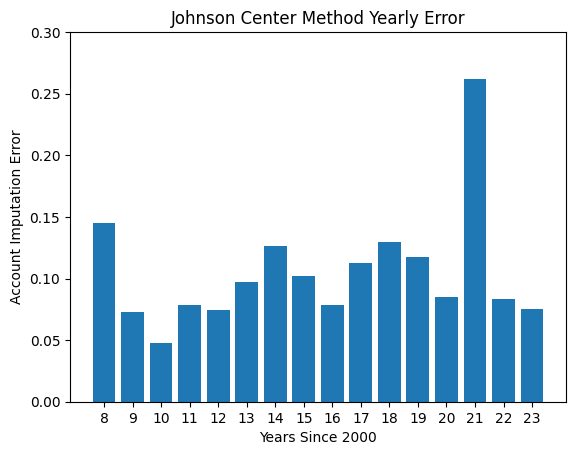

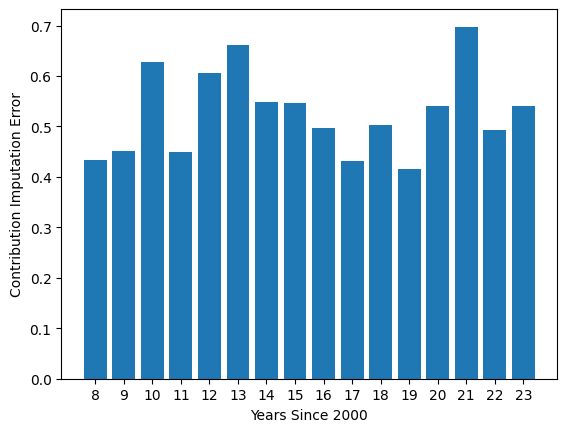

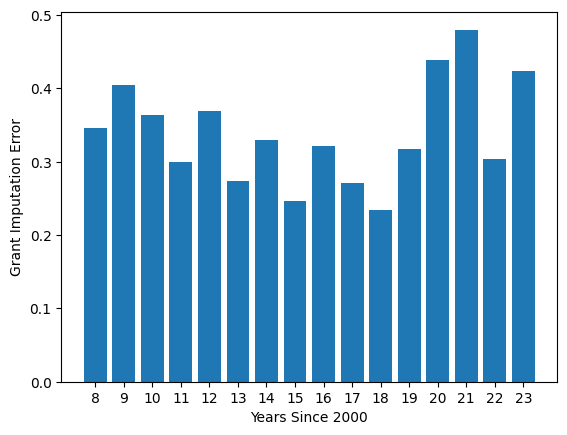

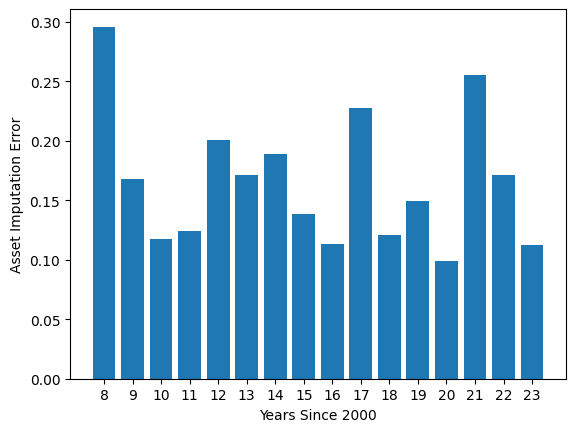

In [ ]:
def relative_grouped_error(actual_col, predicted_col):
    valid_rows = group[group[predicted_col].notna()&group[actual_col].notna()&(group[actual_col] !=0)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
    ME =(abs((total_actual - total_predicted)/total_actual)).median()
    return ME

RE_account_by_year = []
RE_contributions_by_year = []
RE_grants_by_year = []
RE_assets_by_year = []

grouped = df.groupby("Year")
for year, group in grouped:
    RE_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    RE_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    RE_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    RE_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

# def relative_grouped_error(actual_col, predicted_col):
#     valid_rows = group[group[predicted_col].notna()]
#     total_actual = valid_rows[actual_col].sum()
#     total_predicted = valid_rows[predicted_col].sum()
#     RE = abs((total_actual - total_predicted) / total_actual)
#     return RE

community_account_by_year = []
community_contributions_by_year = []
community_grants_by_year = []
community_assets_by_year = []

national_account_by_year = []
national_contributions_by_year = []
national_grants_by_year = []
national_assets_by_year = []

single_account_by_year = []
single_contributions_by_year = []
single_grants_by_year = []
single_assets_by_year = []

community_df = df[df["Type"] == "Community Foundation"]
cgroups = community_df.groupby("subtype")
for subtype, group in cgroups:
    community_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    community_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    community_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    community_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

national_df = df[df["Type"] == "National"]
ngroups = national_df.groupby("subtype")
for subtype, group in ngroups:
    national_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    national_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    national_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    national_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

single_df = df[df["Type"] == "Single Issue Charity"]
sgroups = single_df.groupby("subtype")
for subtype, group in sgroups:
    single_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    single_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    single_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    single_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))
#2024 is discounted from these graphs because the error is exponentially greater than the rest
#2020/2021 was Covid, 2014 was when the stock market rebounded, and 2008/2009 was an economic recession
account_error_by_year = RE_account_by_year[1:-1]
contribution_error_by_year = RE_contributions_by_year[1:-1]
grant_error_by_year = RE_grants_by_year[1:-1]
asset_error_by_year = RE_assets_by_year[1:-1]

Year = range(7, 23)

plt.bar(Year, account_error_by_year)
plt.title("Johnson Center Method Yearly Error")
plt.xlabel("Years Since 2000")
plt.ylabel("Account Imputation Error")
plt.ylim(0,0.3)
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, contribution_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Contribution Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, grant_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Grant Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, asset_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Asset Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()